# **Model-Based Deep-Learning Approaches based on ADMM for Robust PCA in Internet Traffic Decomposition**

## **From Pure Model-Based Optimization to Adaptive Model-Based Deep Learning**

This notebook studies Robust Principal Component Analysis (RPCA) for internet traffic decomposition under the model:

\[
Y = $L_0$ + $S_0$ + N
\]

where:

- \( $L_0$ \) = low-rank nominal traffic  
- \( $S_0$ \) = sparse structured anomalies  
- \( N \) = noise  
- \( Y \) = observed traffic matrix  

The objective is not pure anomaly detection, but **accurate reconstruction of the low-rank and sparse components**, improving over classical optimization through learning-based extensions.

---
## Implemented Approaches

We progressively move from fully model-based ADMM to deep unfolded and hybrid architectures:

- **RUN1 — ADMM (Ideal)**  
  Classical ADMM evaluated on the theoretical dataset (matched assumptions).

- **RUN2 — ADMM (Baseline Mismatch)**  
  Same ADMM configuration evaluated under dataset mismatch conditions.

- **RUN3 — Global-Learned ADMM**  
  ADMM with globally learned hyperparameters.

- **RUN4 — Layer-wise Unfolded ADMM**  
  Deep unfolding of ADMM with layer-wise learnable parameters.

- **RUN5 — Unfolded ADMM + Learned Prox**  
  Unfolded ADMM with a learned proximal operator for the sparse component.

- **RUN6 — Unfolded Hybrid DL Residual ADMM**  
  Hybrid architecture combining model-based structure with residual deep learning.

---

## Evaluation Metrics

Primary reconstruction metrics:

- **NMSE_L** — Normalized Mean Squared Error on the low-rank component  
- **NMSE_S** — Normalized Mean Squared Error on the sparse component  

Secondary analysis:

- Convergence behavior  
- Iteration efficiency  
- Reconstruction stability under mismatch  

---

This notebook highlights the transition from **pure model-based optimization** to **model-driven deep learning**, analyzing when and how learning improves structured matrix decomposition.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Imports
import os, sys, time, math, json
import numpy as np
import matplotlib.pyplot as plt
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)


# Project paths
PROJECT_PATH = "/content/drive/MyDrive/RPCA_Project"
UTILS_PATH = os.path.join(PROJECT_PATH, "utils")
sys.path.append(UTILS_PATH)

# Custom modules
from admm_utils import soft_threshold, admm_rpca, svt
from metrics import compute_nmse
from plotting import save_run_results
print("Custom modules imported successfully.")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Results folders
METRICS_PATH = os.path.join(PROJECT_PATH, "results_metrics")
FIGURES_PATH = os.path.join(PROJECT_PATH, "results_figures")
os.makedirs(METRICS_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)


Custom modules imported successfully.
Using device: cuda


In [ ]:
# Load mismatch dataset (used in RUN2–RUN6) - "v2_traffic_dataset_mismatch.mat" - noise value identical to the ideal dataset

BASE_PATH = "/content/drive/MyDrive/RPCA_Project"
MISM_PATH = os.path.join(BASE_PATH, "v2_traffic_dataset_mismatch.mat")

with h5py.File(MISM_PATH, "r") as f:
    Y_train = np.array(f["Y_train"])
    L0_train = np.array(f["L0_train"])
    S0_train = np.array(f["S0_train"])
    Y_test = np.array(f["Y_test"])
    L0_test = np.array(f["L0_test"])
    S0_test = np.array(f["S0_test"])

Y_train = torch.tensor(Y_train).permute(0, 2, 1).float().to(device)
L0_train = torch.tensor(L0_train).permute(0, 2, 1).float().to(device)
S0_train = torch.tensor(S0_train).permute(0, 2, 1).float().to(device)

Y_test = torch.tensor(Y_test).permute(0, 2, 1).float().to(device)
L0_test = torch.tensor(L0_test).permute(0, 2, 1).float().to(device)
S0_test = torch.tensor(S0_test).permute(0, 2, 1).float().to(device)

num_train, N, T = Y_train.shape
num_test = Y_test.shape[0]

print("Mismatch dataset loaded")
print(f"Train: {Y_train.shape}")
print(f"Test : {Y_test.shape}")


Mismatch dataset loaded
Train: torch.Size([80, 100, 500])
Test : torch.Size([40, 100, 500])


## RUN1 — ADMM (Ideal)

Classical ADMM is evaluated on the theoretical dataset, where the RPCA model assumptions are fully satisfied:

\[
Y = $L_0$ + $S_0$ + N
\]

No learning is involved in this run.  
This experiment serves as the ideal baseline, providing a reference performance under perfectly matched model conditions.



=== RUN1 — ADMM (Ideal) ===
Test samples: 10
Matrix size : 100 x 500
lambda = 0.044721 | rho = 1.0
Test   1/10 | NMSE_L=0.000587 | NMSE_S=0.023596 | Iter=430
Test  10/10 | NMSE_L=0.000594 | NMSE_S=0.023465 | Iter=430

===== RUN1 RESULTS =====
NMSE_L     : 0.000582 ± 0.000016
NMSE_S     : 0.023470 ± 0.000142
Iterations : 431.9 ± 2.9


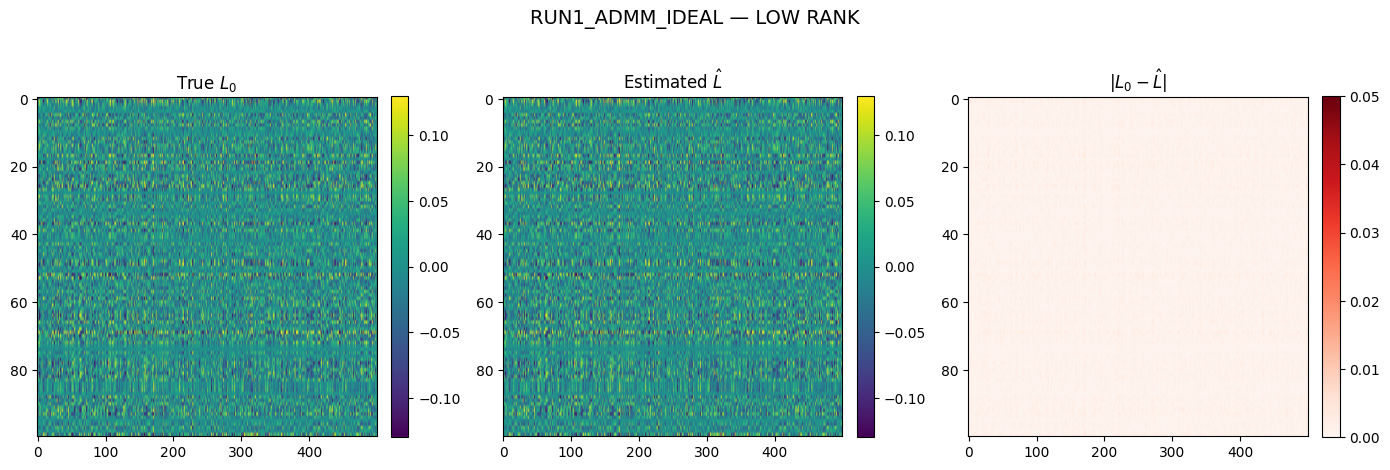

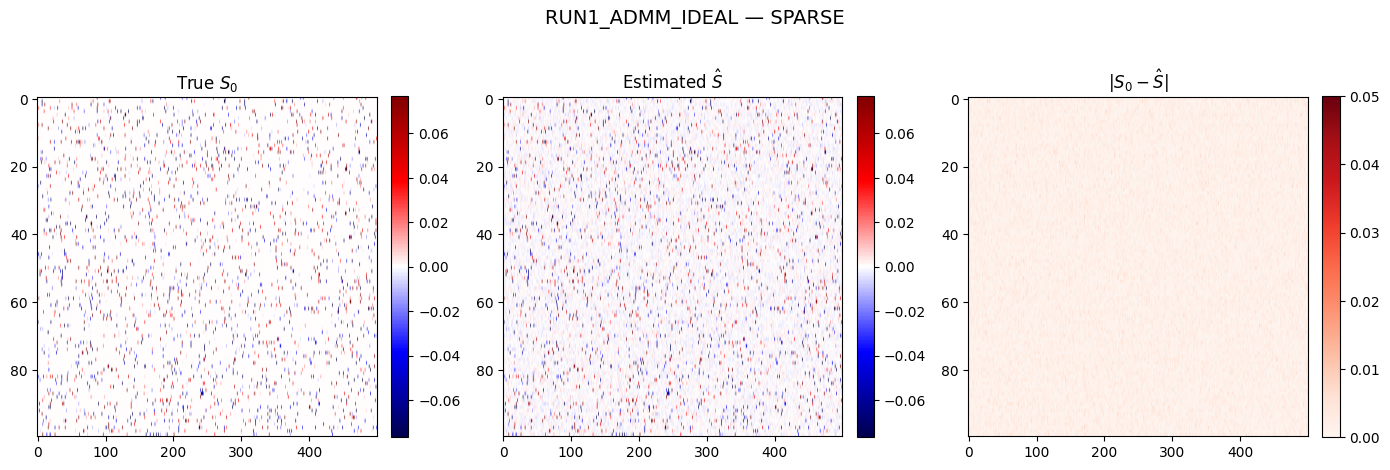

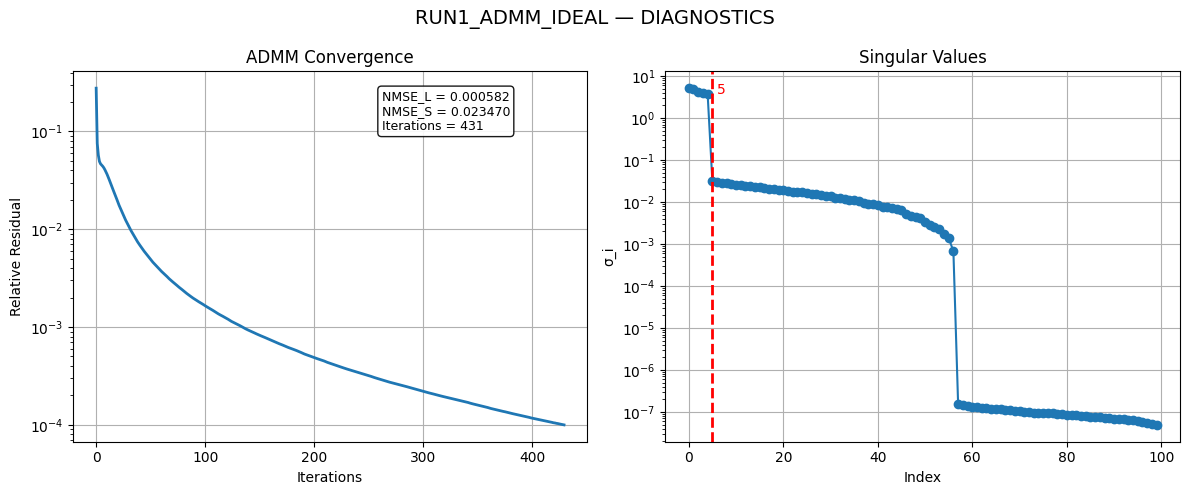

Saved structured figures for RUN1_ADMM_IDEAL

RUN1 COMPLETED.


In [ ]:
# RUN1 — ADMM (Ideal)

print("\n=== RUN1 — ADMM (Ideal) ===")

# Load theoretical dataset

THEORETICAL_DATA_PATH = os.path.join(PROJECT_PATH, "traffic_dataset_theoretical.mat")

with h5py.File(THEORETICAL_DATA_PATH, "r") as f:
    Y_test_theo  = torch.tensor(np.array(f["Y_test"])).permute(0,2,1).float().to(device)
    L0_test_theo = torch.tensor(np.array(f["L0_test"])).permute(0,2,1).float().to(device)
    S0_test_theo = torch.tensor(np.array(f["S0_test"])).permute(0,2,1).float().to(device)

num_test_theo = Y_test_theo.shape[0]
N_theo, T_theo = Y_test_theo.shape[1:]

print(f"Test samples: {num_test_theo}")
print(f"Matrix size : {N_theo} x {T_theo}")

# Hyperparameters

lambda_val = 1 / math.sqrt(max(N_theo, T_theo))
rho = 1.0

print(f"lambda = {lambda_val:.6f} | rho = {rho}")

NMSE_L, NMSE_S, Iterations = [], [], []

L_rep = S_rep = L0_rep = S0_rep = convergence_curve_rep = None

# ADMM evaluation loop

for i in range(num_test_theo):

    L, S, iters, conv = admm_rpca(Y_test_theo[i], lambda_val, rho)

    nmse_L = compute_nmse(L, L0_test_theo[i]).item()
    nmse_S = compute_nmse(S, S0_test_theo[i]).item()

    NMSE_L.append(nmse_L)
    NMSE_S.append(nmse_S)
    Iterations.append(iters)

    if i == 0:
        L_rep = L.detach().cpu().numpy()
        S_rep = S.detach().cpu().numpy()
        L0_rep = L0_test_theo[i].detach().cpu().numpy()
        S0_rep = S0_test_theo[i].detach().cpu().numpy()
        convergence_curve_rep = conv

    if i == 0 or (i+1) % 10 == 0:
        print(f"Test {i+1:3d}/{num_test_theo} | "
              f"NMSE_L={nmse_L:.6f} | "
              f"NMSE_S={nmse_S:.6f} | "
              f"Iter={iters}")

# Aggregate results

NMSE_L = np.array(NMSE_L)
NMSE_S = np.array(NMSE_S)
Iterations = np.array(Iterations)

print("\n===== RUN1 RESULTS =====")
print(f"NMSE_L     : {NMSE_L.mean():.6f} ± {NMSE_L.std():.6f}")
print(f"NMSE_S     : {NMSE_S.mean():.6f} ± {NMSE_S.std():.6f}")
print(f"Iterations : {Iterations.mean():.1f} ± {Iterations.std():.1f}")
print("=================================")

# Save results

save_run_results(
    run_name="RUN1_ADMM_IDEAL",
    nmse_L_list=NMSE_L,
    nmse_S_list=NMSE_S,
    iterations_list=Iterations,
    L0_rep=L0_rep,
    L_hat_rep=L_rep,
    S0_rep=S0_rep,
    S_hat_rep=S_rep,
    convergence_curve=convergence_curve_rep,
    extra_params={"lambda": lambda_val, "rho": rho},
    base_path=PROJECT_PATH
)

print("\nRUN1 COMPLETED.")


## RUN2 — ADMM (Baseline Mismatch)

Classical ADMM is evaluated on the mismatch dataset.

The RPCA model is still assumed, but the data no longer perfectly satisfy the theoretical assumptions.  
No learning is involved in this run.

This experiment measures the degradation of pure model-based ADMM under model mismatch conditions.



=== RUN2 — ADMM (Baseline Mismatch) ===
lambda = 0.044721 | rho = 1.0

Running ADMM on full test set...

Test   1/40 | NMSE_L=0.028365 | NMSE_S=0.327464 | Iter=466
Test  10/40 | NMSE_L=0.036895 | NMSE_S=0.422961 | Iter=456
Test  20/40 | NMSE_L=0.044710 | NMSE_S=0.510351 | Iter=470
Test  30/40 | NMSE_L=0.037127 | NMSE_S=0.426016 | Iter=458
Test  40/40 | NMSE_L=0.045845 | NMSE_S=0.523721 | Iter=459

===== RUN2 RESULTS =====
NMSE_L     : 0.035330 ± 0.006950
NMSE_S     : 0.405560 ± 0.077037
Iterations : 464.9 ± 6.0


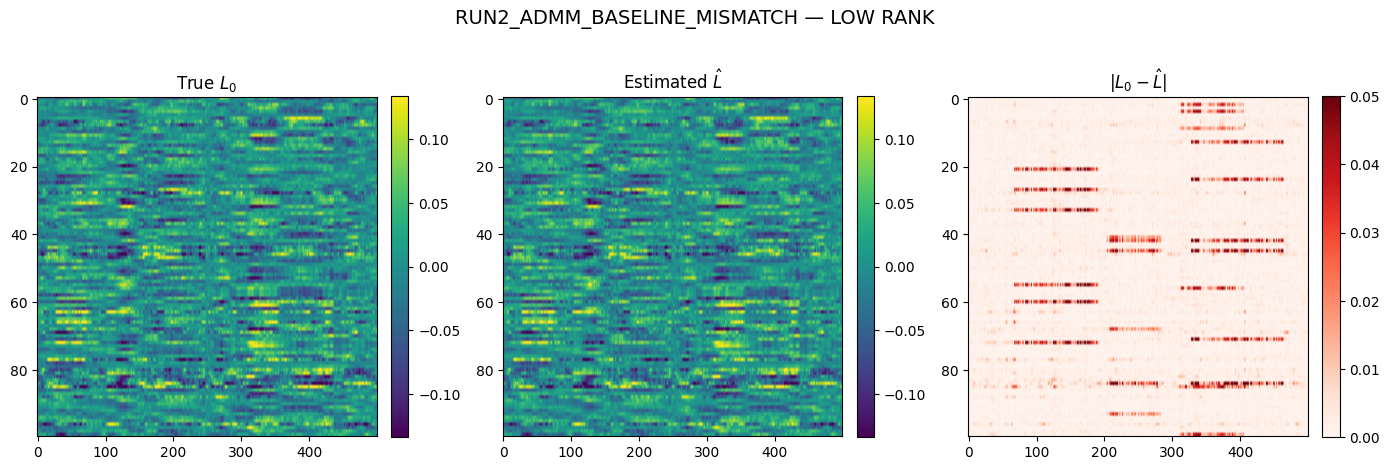

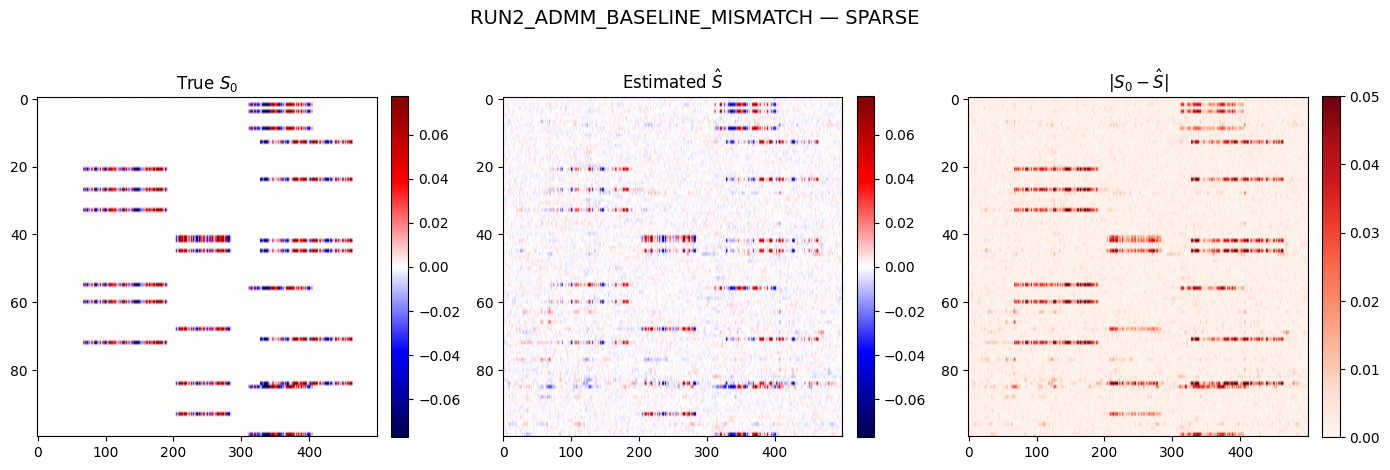

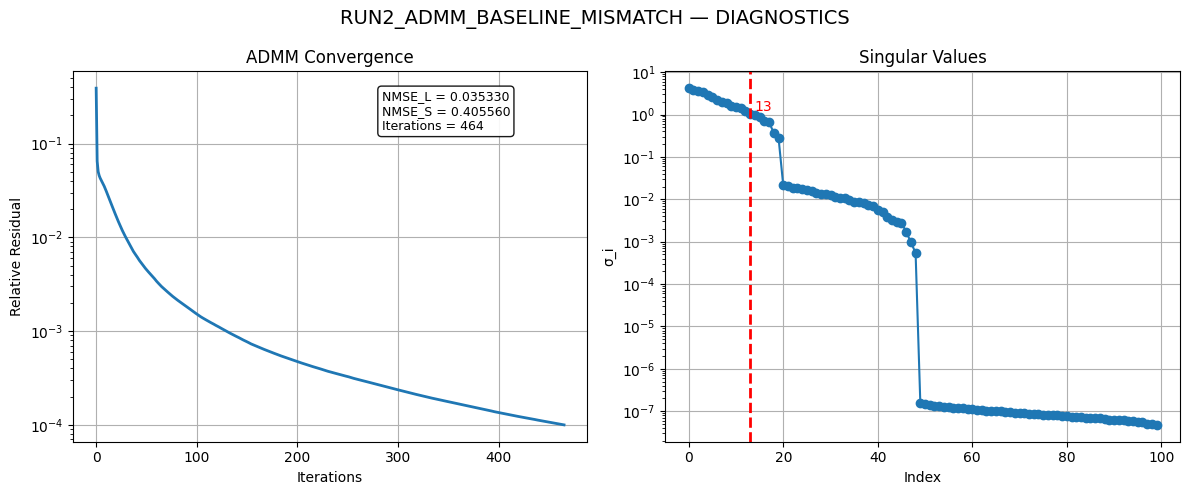

Saved structured figures for RUN2_ADMM_BASELINE_MISMATCH

RUN2 COMPLETED.


In [ ]:
# RUN2 — ADMM (Baseline Mismatch)

print("\n=== RUN2 — ADMM (Baseline Mismatch) ===")

num_test = Y_test.shape[0]
N, T = Y_test.shape[1:]

lambda_reg = 1 / math.sqrt(max(N, T))
rho = 1.0
max_iter = 2000
tol = 1e-4

print(f"lambda = {lambda_reg:.6f} | rho = {rho}")
print("\nRunning ADMM on full test set...\n")

NMSE_L, NMSE_S, Iterations = [], [], []
L_rep = S_rep = L0_rep = S0_rep = convergence_curve_rep = None

for i in range(num_test):

    L, S, iters, conv = admm_rpca(
        Y_test[i],
        lambda_reg,
        rho,
        max_iter=max_iter,
        tol=tol
    )

    nmse_L = compute_nmse(L, L0_test[i]).item()
    nmse_S = compute_nmse(S, S0_test[i]).item()

    NMSE_L.append(nmse_L)
    NMSE_S.append(nmse_S)
    Iterations.append(iters)

    if i == 0:
        L_rep = L.detach().cpu().numpy()
        S_rep = S.detach().cpu().numpy()
        L0_rep = L0_test[i].detach().cpu().numpy()
        S0_rep = S0_test[i].detach().cpu().numpy()
        convergence_curve_rep = conv

    if i == 0 or (i+1) % 10 == 0:
        print(f"Test {i+1:3d}/{num_test} | "
              f"NMSE_L={nmse_L:.6f} | "
              f"NMSE_S={nmse_S:.6f} | "
              f"Iter={iters}")

NMSE_L = np.array(NMSE_L)
NMSE_S = np.array(NMSE_S)
Iterations = np.array(Iterations)

print("\n===== RUN2 RESULTS =====")
print(f"NMSE_L     : {NMSE_L.mean():.6f} ± {NMSE_L.std():.6f}")
print(f"NMSE_S     : {NMSE_S.mean():.6f} ± {NMSE_S.std():.6f}")
print(f"Iterations : {Iterations.mean():.1f} ± {Iterations.std():.1f}")
print("=================================")

save_run_results(
    run_name="RUN2_ADMM_BASELINE_MISMATCH",
    nmse_L_list=NMSE_L,
    nmse_S_list=NMSE_S,
    iterations_list=Iterations,
    L0_rep=L0_rep,
    L_hat_rep=L_rep,
    S0_rep=S0_rep,
    S_hat_rep=S_rep,
    convergence_curve=convergence_curve_rep,
    layerwise_nmse_L=None,
    layerwise_nmse_S=None,
    extra_params={
        "lambda": lambda_reg,
        "rho": rho,
        "max_iter": max_iter,
        "tol": tol
    },
    base_path=PROJECT_PATH
)

print("\nRUN2 COMPLETED.")


## RUN3 — Global-Learned ADMM

ADMM hyperparameters are selected using a grid search on a subset of the training data.

The optimal global values are chosen by minimizing a joint reconstruction score based on both low-rank and sparse NMSE.

The selected hyperparameters are then evaluated on the full test set.

No unfolding or learned operators are introduced yet.  
This run improves classical ADMM through data-driven hyperparameter selection.



=== RUN3 — Global-Learned ADMM ===

--- Grid search (train) ---
lambda=0.01118 | rho=0.50 | score=3.337501
lambda=0.01118 | rho=0.75 | score=3.337502
lambda=0.01118 | rho=1.00 | score=3.337502
lambda=0.01118 | rho=1.25 | score=3.337502
lambda=0.01118 | rho=1.50 | score=3.337502
lambda=0.01118 | rho=2.00 | score=3.337502
lambda=0.02236 | rho=0.50 | score=1.256514
lambda=0.02236 | rho=0.75 | score=1.257917
lambda=0.02236 | rho=1.00 | score=1.252574
lambda=0.02236 | rho=1.25 | score=1.266732
lambda=0.02236 | rho=1.50 | score=1.277252
lambda=0.02236 | rho=2.00 | score=1.272320
lambda=0.03354 | rho=0.50 | score=0.109509
lambda=0.03354 | rho=0.75 | score=0.109557
lambda=0.03354 | rho=1.00 | score=0.109646
lambda=0.03354 | rho=1.25 | score=0.109793
lambda=0.03354 | rho=1.50 | score=0.109993
lambda=0.03354 | rho=2.00 | score=0.110950
lambda=0.04472 | rho=0.50 | score=0.118160
lambda=0.04472 | rho=0.75 | score=0.118156
lambda=0.04472 | rho=1.00 | score=0.118151
lambda=0.04472 | rho=1.25 | scor

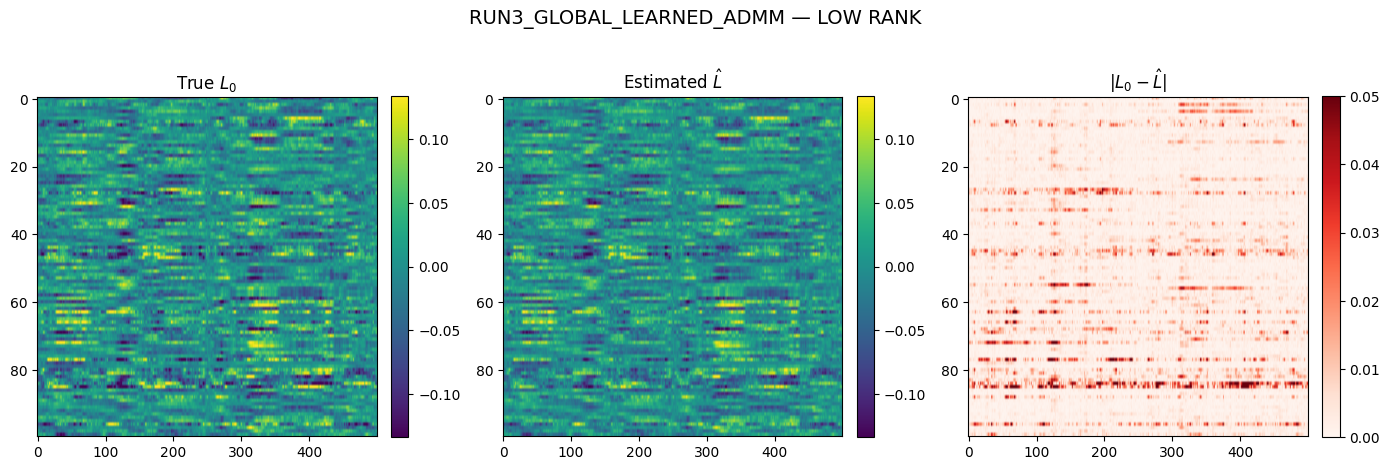

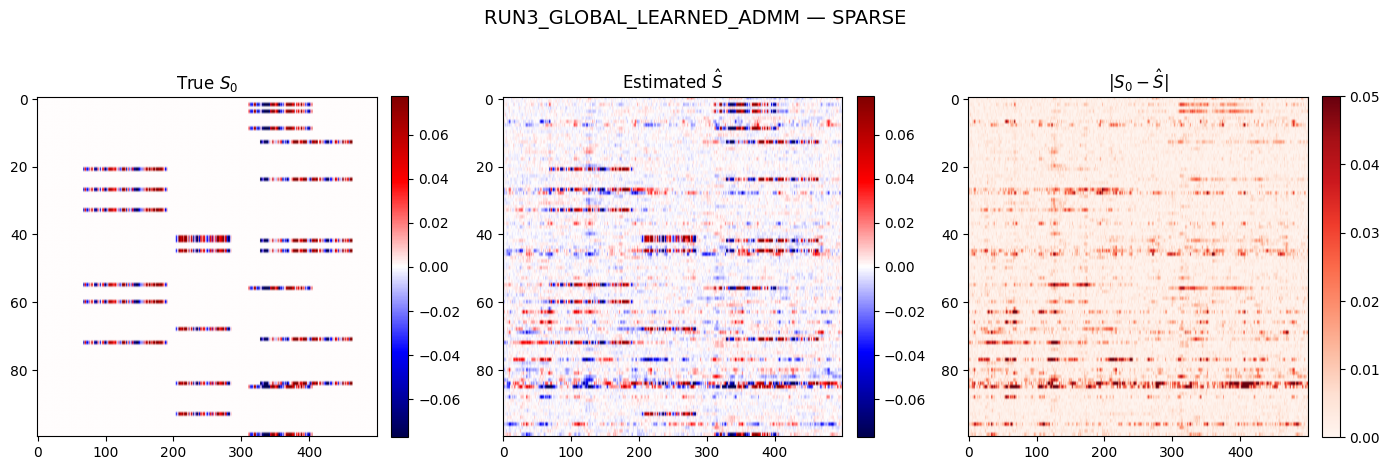

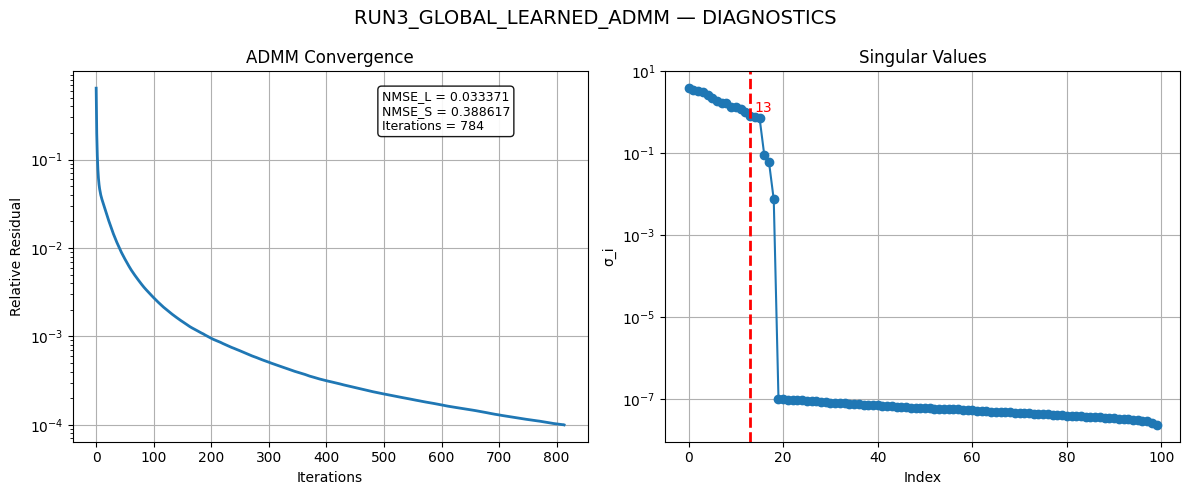

Saved structured figures for RUN3_GLOBAL_LEARNED_ADMM

RUN3 COMPLETED.


In [ ]:
# RUN3 — Global-Learned ADMM

print("\n=== RUN3 — Global-Learned ADMM ===")

num_train = Y_train.shape[0]
num_test  = Y_test.shape[0]
N, T      = Y_train.shape[1:]

max_iter_train, tol_train = 300, 1e-3
max_iter_test,  tol_test  = 2000, 1e-4


# Grid search on training subset

print("\n--- Grid search (train) ---")

lambda0 = 1 / math.sqrt(max(N, T))
lambda_grid = lambda0 * np.array([0.25, 0.5, 0.75, 1, 1.25, 1.5, 2])
rho_grid = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 2.0])

train_subset = min(25, num_train)

best_score = float("inf")
lambda_best = rho_best = None

for lambda_reg in lambda_grid:
    for rho in rho_grid:

        scores = []

        for idx in range(train_subset):

            L, S, _, _ = admm_rpca(
                Y_train[idx],
                lambda_reg,
                rho,
                max_iter=max_iter_train,
                tol=tol_train
            )

            nmse_L = compute_nmse(L, L0_train[idx]).item()
            nmse_S = compute_nmse(S, S0_train[idx]).item()
            scores.append(math.sqrt(nmse_L * nmse_S))

        mean_score = np.mean(scores)

        print(f"lambda={lambda_reg:.5f} | rho={rho:.2f} | score={mean_score:.6f}")

        if mean_score < best_score:
            best_score = mean_score
            lambda_best = float(lambda_reg)
            rho_best = float(rho)


print("\nBest hyperparameters (train)")
print(f"lambda_best = {lambda_best:.6f}")
print(f"rho_best    = {rho_best:.6f}")
print(f"score       = {best_score:.6f}")


# Test with learned hyperparameters

print("\n--- Testing with learned hyperparameters ---")

NMSE_L, NMSE_S, Iterations = [], [], []
L_rep = S_rep = L0_rep = S0_rep = convergence_curve_rep = None

for i in range(num_test):

    L, S, iters, conv = admm_rpca(
        Y_test[i],
        lambda_best,
        rho_best,
        max_iter=max_iter_test,
        tol=tol_test
    )

    nmse_L = compute_nmse(L, L0_test[i]).item()
    nmse_S = compute_nmse(S, S0_test[i]).item()

    NMSE_L.append(nmse_L)
    NMSE_S.append(nmse_S)
    Iterations.append(iters)

    if i == 0:
        L_rep = L.detach().cpu().numpy()
        S_rep = S.detach().cpu().numpy()
        L0_rep = L0_test[i].detach().cpu().numpy()
        S0_rep = S0_test[i].detach().cpu().numpy()
        convergence_curve_rep = conv

    if i == 0 or (i+1) % 10 == 0:
        print(f"Test {i+1:3d}/{num_test} | "
              f"NMSE_L={nmse_L:.6f} | "
              f"NMSE_S={nmse_S:.6f} | "
              f"Iter={iters}")


# Aggregate results

NMSE_L = np.array(NMSE_L)
NMSE_S = np.array(NMSE_S)
Iterations = np.array(Iterations)

print("\n===== RUN3 RESULTS =====")
print(f"NMSE_L     : {NMSE_L.mean():.6f} ± {NMSE_L.std():.6f}")
print(f"NMSE_S     : {NMSE_S.mean():.6f} ± {NMSE_S.std():.6f}")
print(f"Iterations : {Iterations.mean():.1f} ± {Iterations.std():.1f}")
print("=================================")


# Save results

save_run_results(
    run_name="RUN3_GLOBAL_LEARNED_ADMM",
    nmse_L_list=NMSE_L,
    nmse_S_list=NMSE_S,
    iterations_list=Iterations,
    L0_rep=L0_rep,
    L_hat_rep=L_rep,
    S0_rep=S0_rep,
    S_hat_rep=S_rep,
    convergence_curve=convergence_curve_rep,
    extra_params={
        "lambda_best": lambda_best,
        "rho_best": rho_best,
        "train_score": best_score
    },
    base_path=PROJECT_PATH
)

print("\nRUN3 COMPLETED.")


## RUN4 — Layer-wise Unfolded ADMM

ADMM is unfolded into a finite-depth architecture with K layers.

Each layer has learnable ADMM hyperparameters $\lambda_k$ and $\rho_k$,
which are optimized through backpropagation on the training set.


The algorithmic structure of ADMM is preserved, but the parameters become layer-dependent and data-driven.

This run introduces model-based deep learning through unfolding, while keeping the original proximal operators unchanged.



=== RUN4 — Layer-wise Unfolded ADMM ===
Layers: 10
Training...

Epoch   1 | Train 0.482657 | Val 0.487441
Epoch   2 | Train 0.467237 | Val 0.474251
Epoch   3 | Train 0.455677 | Val 0.461669
Epoch   4 | Train 0.443919 | Val 0.449700
Epoch   5 | Train 0.430095 | Val 0.438312
Epoch   6 | Train 0.420083 | Val 0.427347
Epoch   7 | Train 0.409783 | Val 0.416886
Epoch   8 | Train 0.398603 | Val 0.406923
Epoch   9 | Train 0.387978 | Val 0.397320
Epoch  10 | Train 0.379869 | Val 0.388264
Epoch  11 | Train 0.370871 | Val 0.379433
Epoch  12 | Train 0.360362 | Val 0.370946
Epoch  13 | Train 0.351827 | Val 0.362837
Epoch  14 | Train 0.344414 | Val 0.355024
Epoch  15 | Train 0.337234 | Val 0.347590
Epoch  16 | Train 0.328600 | Val 0.340466
Epoch  17 | Train 0.319256 | Val 0.333651
Epoch  18 | Train 0.316458 | Val 0.327179
Epoch  19 | Train 0.305852 | Val 0.320978
Epoch  20 | Train 0.301251 | Val 0.315131
Epoch  21 | Train 0.296676 | Val 0.309599
Epoch  22 | Train 0.290210 | Val 0.304301
Epoch  23 |

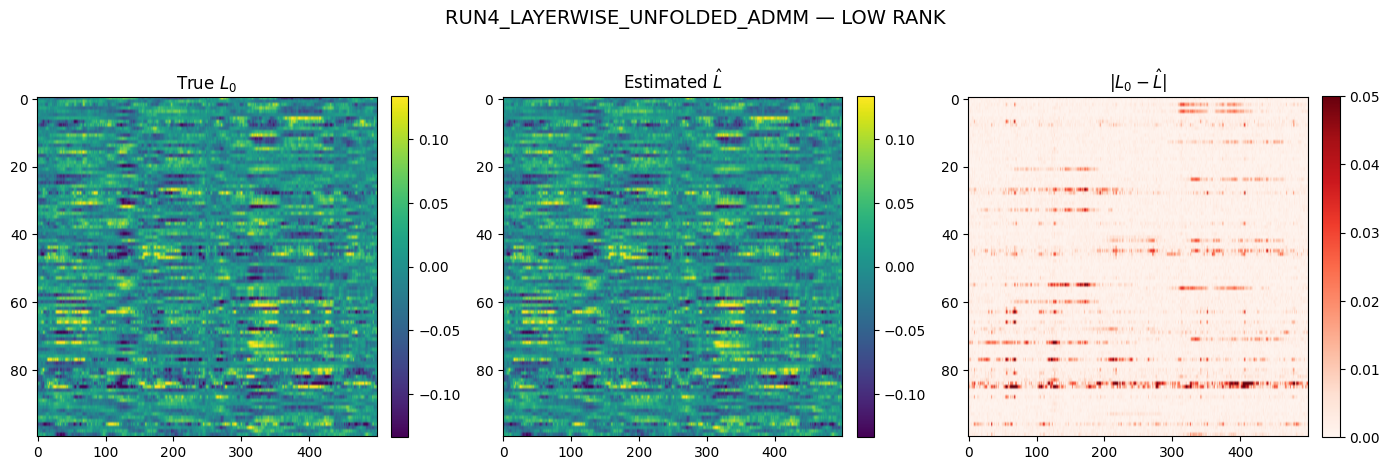

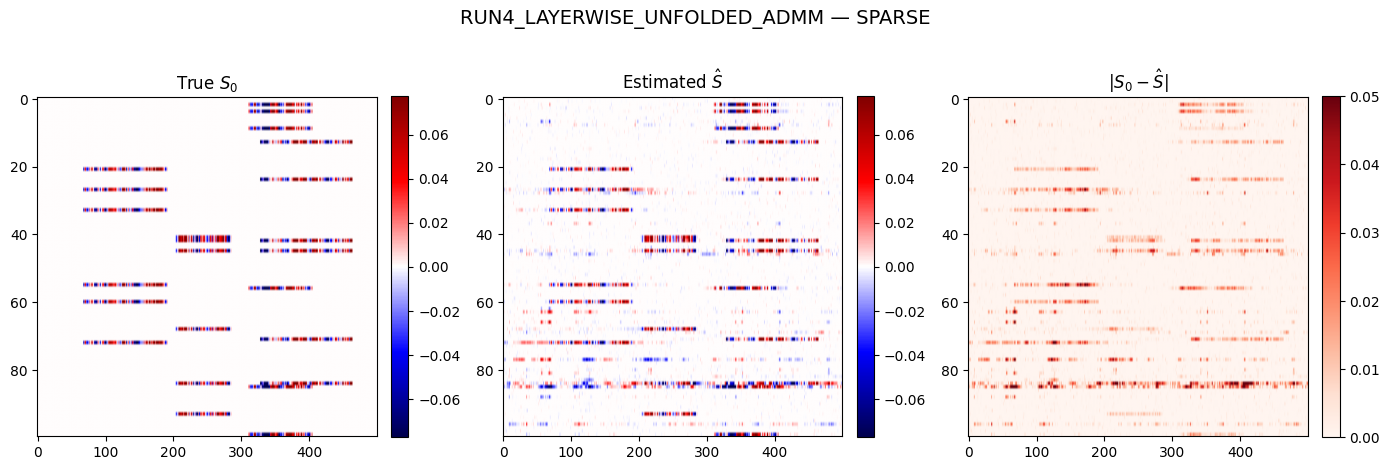

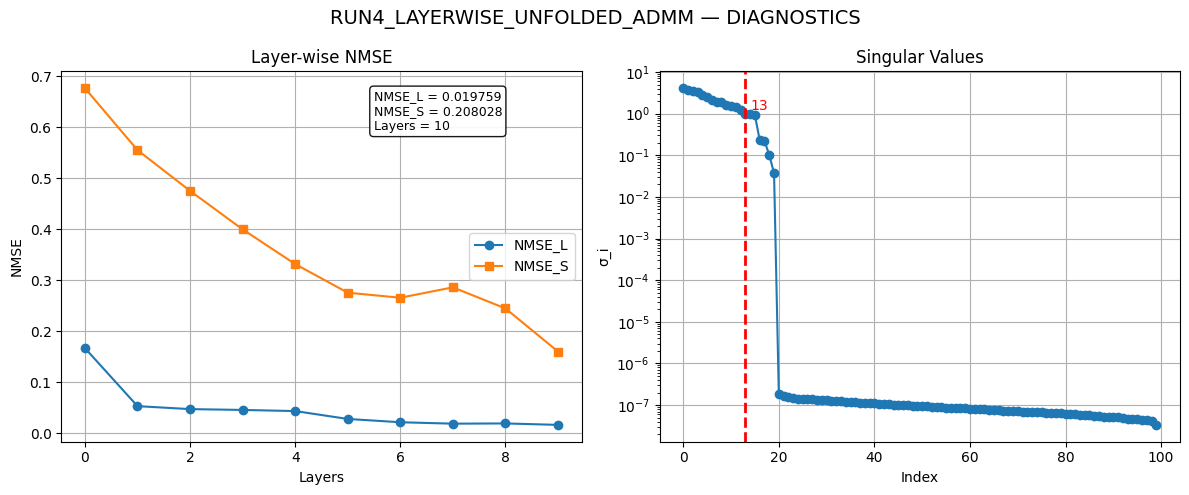

Saved structured figures for RUN4_LAYERWISE_UNFOLDED_ADMM

RUN4 COMPLETED.


In [ ]:
# RUN4 — Layer-wise Unfolded ADMM

print("\n=== RUN4 — Layer-wise Unfolded ADMM ===")


# Model

class UnfoldedADMM(nn.Module):
    def __init__(self, K, lambda_init, rho_init):
        super().__init__()
        self.K = K
        self.log_lambda = nn.Parameter(torch.log(torch.ones(K) * lambda_init))
        self.log_rho = nn.Parameter(torch.log(torch.ones(K) * rho_init))

    def forward(self, Y, L0=None, S0=None, return_curve=False):

        L = torch.zeros_like(Y)
        S = torch.zeros_like(Y)
        U = torch.zeros_like(Y)

        nmse_L_curve, nmse_S_curve = [], []

        for k in range(self.K):

            lambda_k = torch.exp(self.log_lambda[k])
            rho_k = torch.exp(self.log_rho[k])

            # ADMM updates
            L = svt(Y - S + U, 1.0 / rho_k)
            S = soft_threshold(Y - L + U, lambda_k / rho_k)
            U = U + (Y - L - S)

            # Optional layer-wise NMSE tracking
            if return_curve and (L0 is not None) and (S0 is not None):
                nmse_L_curve.append(compute_nmse(L, L0).item())
                nmse_S_curve.append(compute_nmse(S, S0).item())

        if return_curve:
            return L, S, nmse_L_curve, nmse_S_curve
        return L, S


# Hyperparameters

K = 10
epochs = 100
batch_size = 4
lr = 5e-4
patience = 10

lambda_init = 1 / math.sqrt(max(N, T))
rho_init = 2.0

model = UnfoldedADMM(K, lambda_init, rho_init).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)


# Train / validation split

val_size = 10
train_idx = list(range(val_size, num_train))
val_idx = list(range(val_size))

best_val_loss = float("inf")
patience_counter = 0

print(f"Layers: {K}")
print("Training...\n")


# Training loop

for epoch in range(epochs):

    model.train()
    train_loss = 0.0
    perm = torch.randperm(len(train_idx))

    for i in range(0, len(train_idx), batch_size):

        batch_ids = [train_idx[j.item()] for j in perm[i:i+batch_size]]

        Y = Y_train[batch_ids]
        L0 = L0_train[batch_ids]
        S0 = S0_train[batch_ids]

        L_hat, S_hat = model(Y)
        loss = compute_nmse(L_hat, L0) + compute_nmse(S_hat, S0)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= (len(train_idx) / batch_size)

    # Validation

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for i in val_idx:
            Y = Y_train[i:i+1]
            L0 = L0_train[i:i+1]
            S0 = S0_train[i:i+1]

            L_hat, S_hat = model(Y)
            val_loss += (compute_nmse(L_hat, L0) +
                         compute_nmse(S_hat, S0)).item()

    val_loss /= len(val_idx)

    print(f"Epoch {epoch+1:3d} | Train {train_loss:.6f} | Val {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


# Restore best model

model.load_state_dict(best_state)


# Test

print("\nTesting RUN4...\n")

model.eval()

with torch.no_grad():

    L_hat, S_hat = model(Y_test)
    nmse_L = compute_nmse(L_hat, L0_test).item()
    nmse_S = compute_nmse(S_hat, S0_test).item()

    # Layer-wise NMSE curve (first test sample)
    _, _, nmse_L_curve, nmse_S_curve = model(
        Y_test[0:1],
        L0_test[0:1],
        S0_test[0:1],
        return_curve=True
    )

print("===== RUN4 FINAL RESULTS =====")
print(f"NMSE_L : {nmse_L:.6f}")
print(f"NMSE_S : {nmse_S:.6f}")
print(f"Layers : {K}")
print("================================")


# Save results

L_rep = L_hat[0].detach().cpu().numpy()
S_rep = S_hat[0].detach().cpu().numpy()
L0_rep = L0_test[0].detach().cpu().numpy()
S0_rep = S0_test[0].detach().cpu().numpy()

save_run_results(
    run_name="RUN4_LAYERWISE_UNFOLDED_ADMM",
    nmse_L_list=[nmse_L],
    nmse_S_list=[nmse_S],
    iterations_list=[K],
    L0_rep=L0_rep,
    L_hat_rep=L_rep,
    S0_rep=S0_rep,
    S_hat_rep=S_rep,
    convergence_curve=None,
    layerwise_nmse_L=nmse_L_curve,
    layerwise_nmse_S=nmse_S_curve,
    extra_params={
        "K": K,
        "epochs": epoch+1,
        "lambda_init": lambda_init,
        "rho_init": rho_init
    },
    base_path=PROJECT_PATH
)

print("\nRUN4 COMPLETED.")


## RUN5 — Unfolded ADMM + Learned Prox

ADMM is unfolded into K layers as in RUN4, but the sparse proximal operator is replaced by a learnable neural network.

The algorithmic structure of ADMM is preserved, while the sparse update becomes data-driven.

This introduces a stronger form of model-based deep learning, allowing the network to compensate for model mismatch through a learned proximal mapping.



=== RUN5 — Unfolded ADMM + Learned Prox ===
Layers: 10
Training...

Epoch   1 | Train 11.545870 | Val 10.182267
Epoch   2 | Train 9.687322 | Val 8.490105
Epoch   3 | Train 7.511828 | Val 5.835361
Epoch   4 | Train 4.556109 | Val 3.094640
Epoch   5 | Train 2.633386 | Val 2.319734
Epoch   6 | Train 2.267580 | Val 2.150781
Epoch   7 | Train 2.201985 | Val 2.154635
Epoch   8 | Train 2.152865 | Val 2.062503
Epoch   9 | Train 2.104846 | Val 2.019631
Epoch  10 | Train 2.057369 | Val 1.957220
Epoch  11 | Train 1.890743 | Val 1.716461
Epoch  12 | Train 1.623144 | Val 1.458326
Epoch  13 | Train 1.393545 | Val 1.233053
Epoch  14 | Train 1.224922 | Val 1.095192
Epoch  15 | Train 1.138050 | Val 1.085328
Epoch  16 | Train 1.074077 | Val 0.986008
Epoch  17 | Train 0.992268 | Val 0.932880
Epoch  18 | Train 0.927225 | Val 0.876470
Epoch  19 | Train 0.860063 | Val 0.821362
Epoch  20 | Train 0.809943 | Val 0.770000
Epoch  21 | Train 0.753730 | Val 0.701278
Epoch  22 | Train 0.699394 | Val 0.650067
Epoch

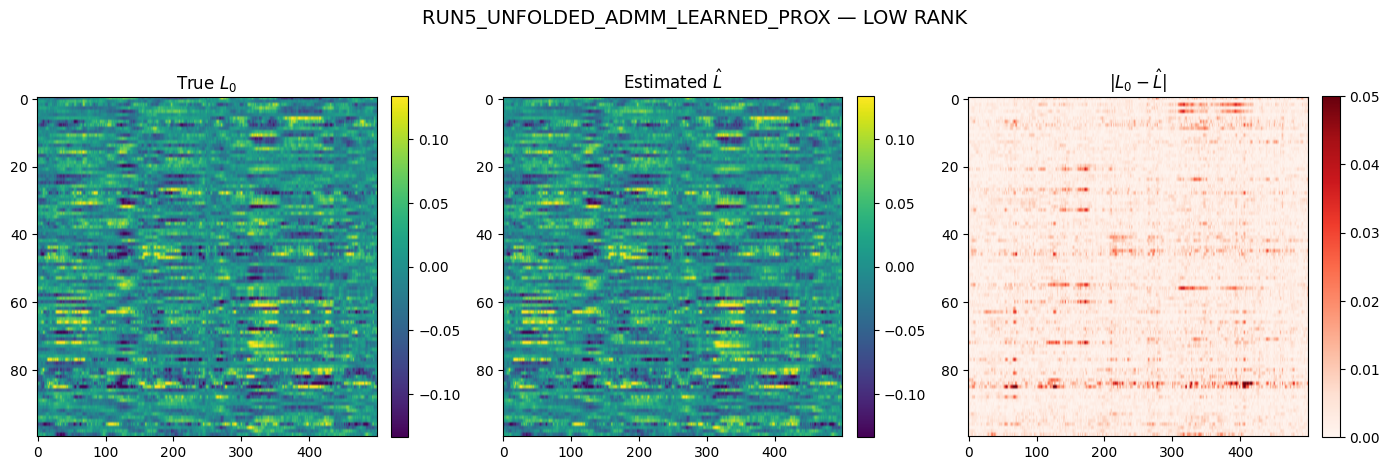

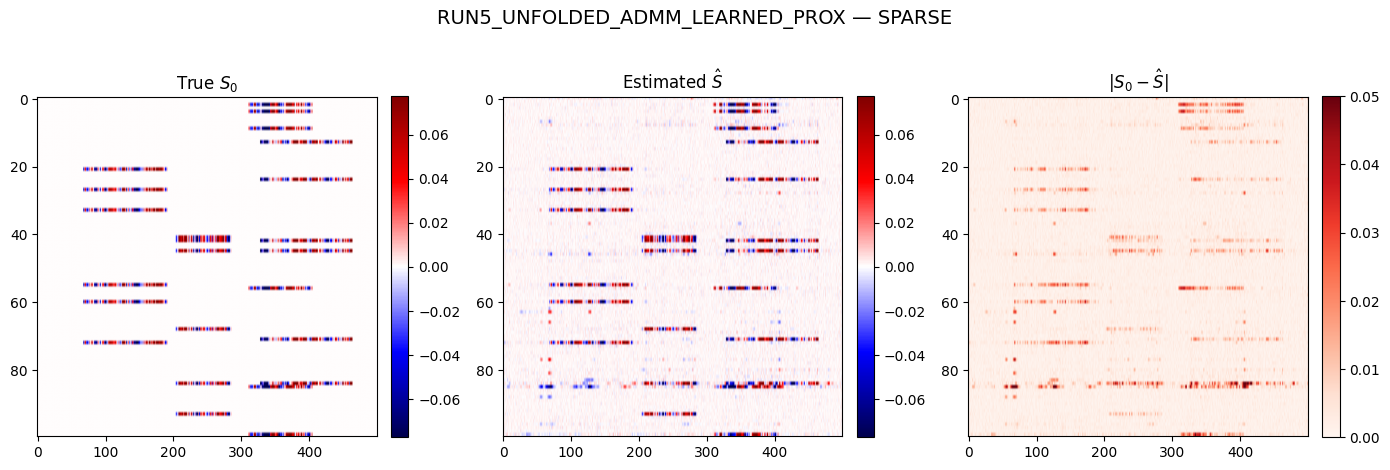

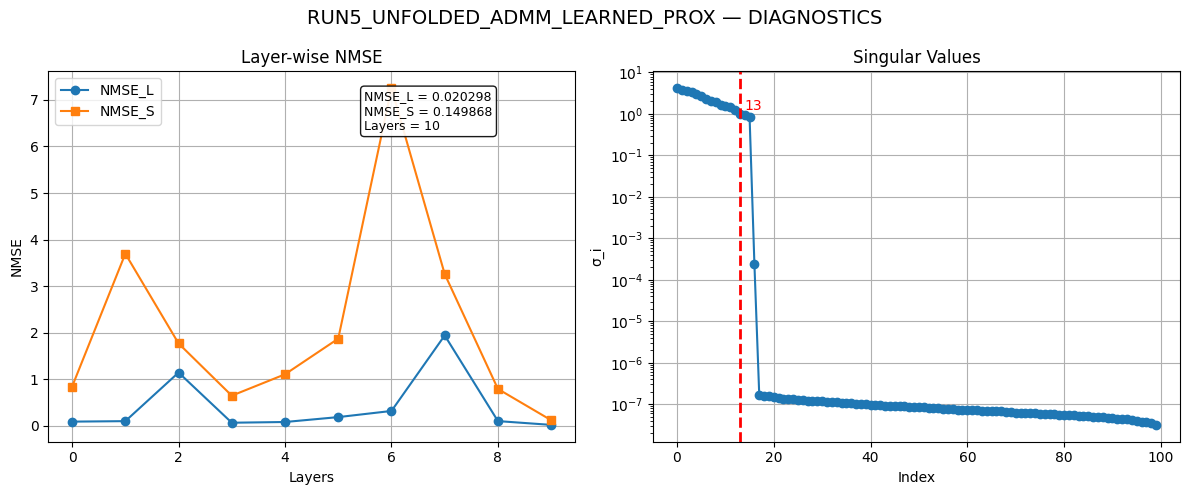

Saved structured figures for RUN5_UNFOLDED_ADMM_LEARNED_PROX

RUN5 COMPLETED.


In [ ]:
# RUN5 — Unfolded ADMM + Learned Prox

print("\n=== RUN5 — Unfolded ADMM + Learned Prox ===")


# Sparse proximal network

class SparseProx(nn.Module):
    def __init__(self, channels=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, 1, 3, padding=1)
        )
        self.alpha = nn.Parameter(torch.tensor(0.1))

    def forward(self, Z):
        correction = self.net(Z)
        return Z - self.alpha * correction


# Deep unfolded ADMM with learned prox

class DeepUnfoldedADMM(nn.Module):
    def __init__(self, K, lambda_init, rho_init):
        super().__init__()
        self.K = K
        self.log_lambda = nn.Parameter(torch.log(torch.ones(K) * lambda_init))
        self.log_rho = nn.Parameter(torch.log(torch.ones(K) * rho_init))
        self.prox_layers = nn.ModuleList([SparseProx(32) for _ in range(K)])

    def forward(self, Y, L0=None, S0=None, return_curve=False):

        L = torch.zeros_like(Y)
        S = torch.zeros_like(Y)
        U = torch.zeros_like(Y)

        nmse_L_curve, nmse_S_curve = [], []

        for k in range(self.K):

            lambda_k = torch.exp(self.log_lambda[k])
            rho_k = torch.exp(self.log_rho[k])

            # ADMM updates
            L = svt(Y - S + U, 1.0 / rho_k)

            Z = Y - L + U
            S = self.prox_layers[k](Z.unsqueeze(1)).squeeze(1)

            U = U + (Y - L - S)

            # Optional layer-wise NMSE tracking
            if return_curve and (L0 is not None) and (S0 is not None):
                nmse_L_curve.append(compute_nmse(L, L0).item())
                nmse_S_curve.append(compute_nmse(S, S0).item())

        if return_curve:
            return L, S, nmse_L_curve, nmse_S_curve
        return L, S


# Hyperparameters

K = 10
epochs = 100
batch_size = 4
lr = 5e-4
patience = 10

lambda_init = 1 / math.sqrt(max(N, T))
rho_init = 2.0

model = DeepUnfoldedADMM(K, lambda_init, rho_init).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)


# Train / validation split

val_size = 10
train_idx = list(range(val_size, num_train))
val_idx = list(range(val_size))

best_val_loss = float("inf")
patience_counter = 0

print(f"Layers: {K}")
print("Training...\n")


# Training loop

for epoch in range(epochs):

    model.train()
    train_loss = 0.0
    perm = torch.randperm(len(train_idx))

    for i in range(0, len(train_idx), batch_size):

        batch_ids = [train_idx[j.item()] for j in perm[i:i+batch_size]]

        Y = Y_train[batch_ids]
        L0 = L0_train[batch_ids]
        S0 = S0_train[batch_ids]

        L_hat, S_hat = model(Y)
        loss = compute_nmse(L_hat, L0) + compute_nmse(S_hat, S0)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= (len(train_idx) / batch_size)

    # Validation

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for i in val_idx:
            Y = Y_train[i:i+1]
            L0 = L0_train[i:i+1]
            S0 = S0_train[i:i+1]

            L_hat, S_hat = model(Y)
            val_loss += (compute_nmse(L_hat, L0) +
                         compute_nmse(S_hat, S0)).item()

    val_loss /= len(val_idx)

    print(f"Epoch {epoch+1:3d} | Train {train_loss:.6f} | Val {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


# Restore best model

model.load_state_dict(best_state)


# Test

print("\nTesting RUN5...\n")

model.eval()

with torch.no_grad():

    L_hat, S_hat = model(Y_test)
    nmse_L = compute_nmse(L_hat, L0_test).item()
    nmse_S = compute_nmse(S_hat, S0_test).item()

    # Layer-wise NMSE curve (first test sample)
    _, _, nmse_L_curve, nmse_S_curve = model(
        Y_test[0:1],
        L0_test[0:1],
        S0_test[0:1],
        return_curve=True
    )

print("===== RUN5 FINAL RESULTS =====")
print(f"NMSE_L : {nmse_L:.6f}")
print(f"NMSE_S : {nmse_S:.6f}")
print(f"Layers : {K}")
print("================================")


# Save results

L_rep = L_hat[0].detach().cpu().numpy()
S_rep = S_hat[0].detach().cpu().numpy()
L0_rep = L0_test[0].detach().cpu().numpy()
S0_rep = S0_test[0].detach().cpu().numpy()

save_run_results(
    run_name="RUN5_UNFOLDED_ADMM_LEARNED_PROX",
    nmse_L_list=[nmse_L],
    nmse_S_list=[nmse_S],
    iterations_list=[K],
    L0_rep=L0_rep,
    L_hat_rep=L_rep,
    S0_rep=S0_rep,
    S_hat_rep=S_rep,
    convergence_curve=None,
    layerwise_nmse_L=nmse_L_curve,
    layerwise_nmse_S=nmse_S_curve,
    extra_params={
        "K": K,
        "epochs": epoch+1,
        "lambda_init": lambda_init,
        "rho_init": rho_init
    },
    base_path=PROJECT_PATH
)

print("\nRUN5 COMPLETED.")


## RUN6 — Hybrid Residual ADMM

ADMM is unfolded into K layers as in the previous runs, but both the low-rank and sparse updates are augmented with learnable residual corrections.

Each layer performs:
- Standard model-based updates (SVT and soft-thresholding)
- Residual CNN corrections added to both L and S

This hybrid architecture preserves the ADMM structure while allowing data-driven residual learning to compensate for model mismatch.

It represents the most expressive model-based deep learning formulation in this study.



=== RUN6 — Hybrid Residual ADMM ===
Layers: 10
Training...

Epoch   1 | Train 0.440924 | Val 0.385899
Epoch   2 | Train 0.350357 | Val 0.340804
Epoch   3 | Train 0.306119 | Val 0.300528
Epoch   4 | Train 0.253656 | Val 0.243461
Epoch   5 | Train 0.203705 | Val 0.197649
Epoch   6 | Train 0.163611 | Val 0.166117
Epoch   7 | Train 0.131779 | Val 0.131313
Epoch   8 | Train 0.104938 | Val 0.124840
Epoch   9 | Train 0.094735 | Val 0.099413
Epoch  10 | Train 0.078465 | Val 0.090263
Epoch  11 | Train 0.071146 | Val 0.097681
Epoch  12 | Train 0.073514 | Val 0.093645
Epoch  13 | Train 0.068110 | Val 0.087946
Epoch  14 | Train 0.065254 | Val 0.075286
Epoch  15 | Train 0.060697 | Val 0.071998
Epoch  16 | Train 0.057999 | Val 0.069821
Epoch  17 | Train 0.056569 | Val 0.072217
Epoch  18 | Train 0.056108 | Val 0.067702
Epoch  19 | Train 0.056980 | Val 0.065991
Epoch  20 | Train 0.055221 | Val 0.070977
Epoch  21 | Train 0.056239 | Val 0.064414
Epoch  22 | Train 0.051548 | Val 0.064068
Epoch  23 | Tra

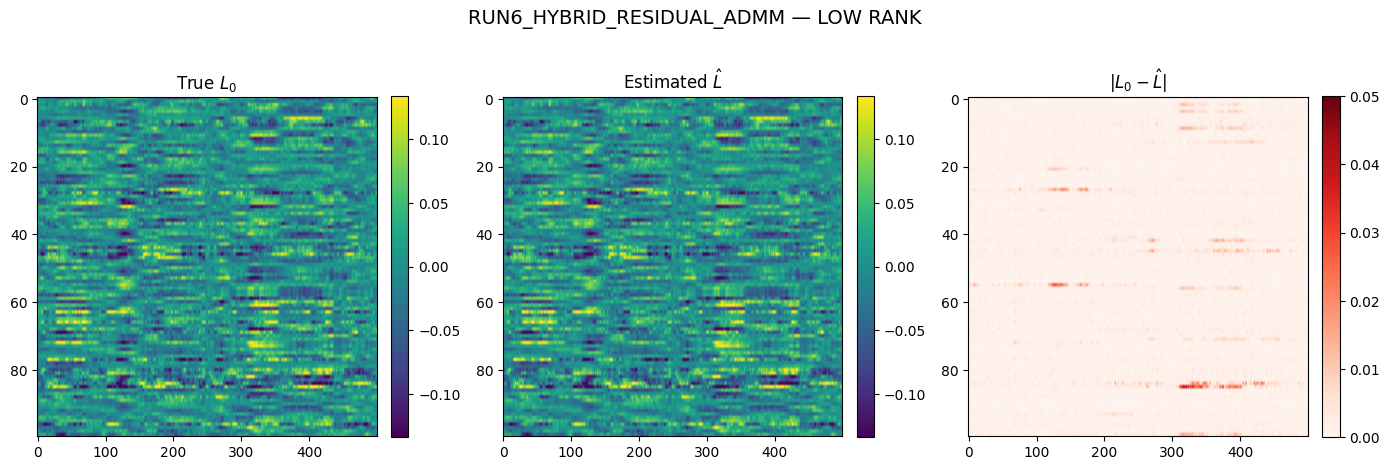

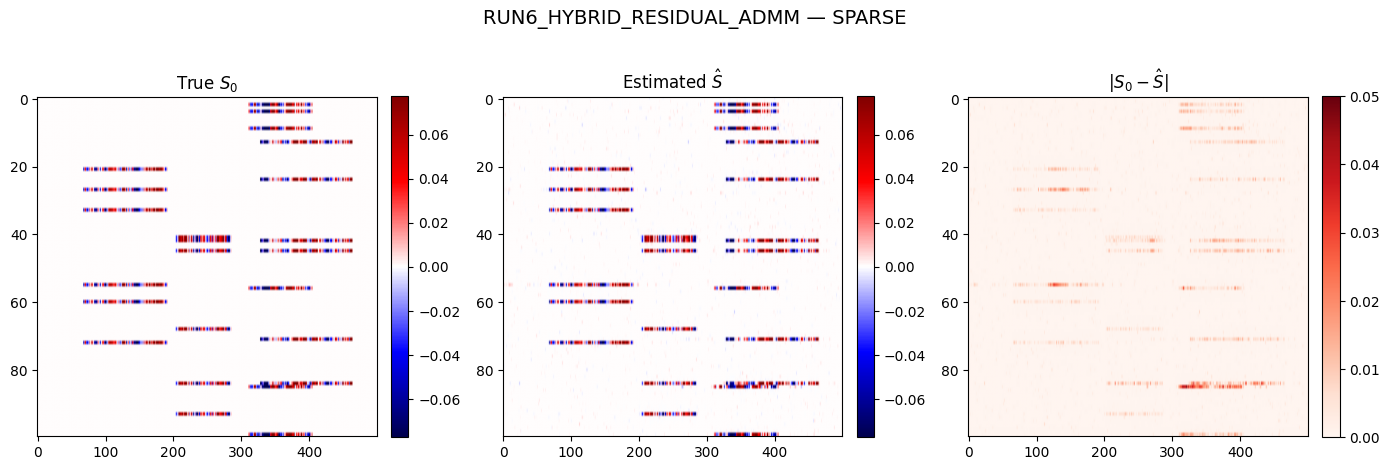

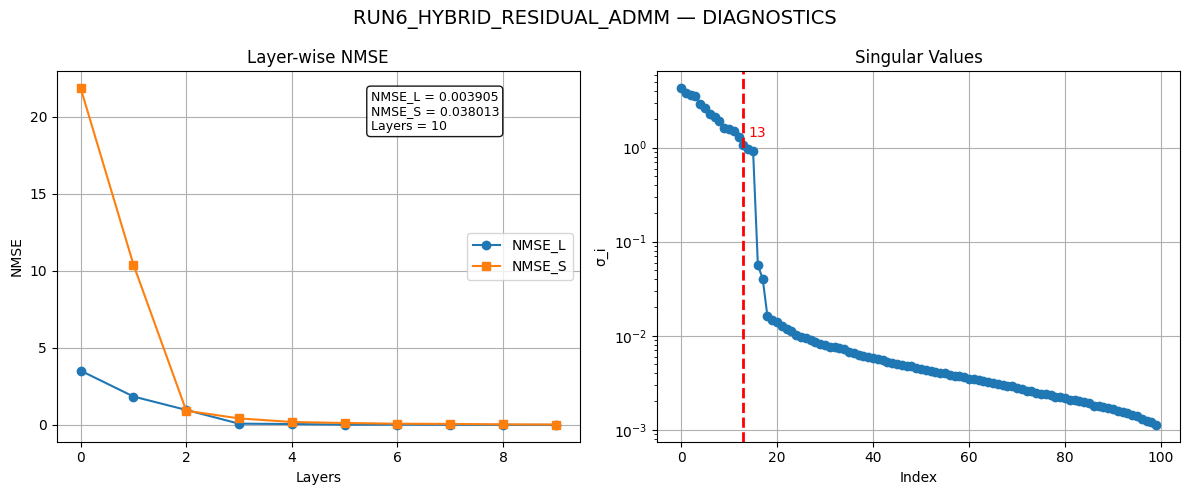

Saved structured figures for RUN6_HYBRID_RESIDUAL_ADMM

RUN6 COMPLETED.


In [ ]:
# RUN6 — Hybrid Residual ADMM

print("\n=== RUN6 — Hybrid Residual ADMM ===")


# Residual CNN block

class ResidualCNN(nn.Module):
    def __init__(self, channels=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, 1, 3, padding=1)
        )
        self.alpha = nn.Parameter(torch.tensor(0.05))

    def forward(self, x):
        return self.alpha * self.net(x)


# Hybrid unfolded ADMM

class DeepHybridADMM(nn.Module):
    def __init__(self, K, lambda_init, rho_init):
        super().__init__()
        self.K = K
        self.log_lambda = nn.Parameter(torch.log(torch.ones(K) * lambda_init))
        self.log_rho = nn.Parameter(torch.log(torch.ones(K) * rho_init))
        self.res_L = nn.ModuleList([ResidualCNN(32) for _ in range(K)])
        self.res_S = nn.ModuleList([ResidualCNN(32) for _ in range(K)])

    def forward(self, Y, L0=None, S0=None, return_curve=False):

        L = torch.zeros_like(Y)
        S = torch.zeros_like(Y)
        U = torch.zeros_like(Y)

        nmse_L_curve, nmse_S_curve = [], []

        for k in range(self.K):

            lambda_k = torch.exp(self.log_lambda[k])
            rho_k = torch.exp(self.log_rho[k])

            # L update (SVT + residual)
            L_svt = svt(Y - S + U, 1.0 / rho_k)
            L = L_svt + self.res_L[k](L_svt.unsqueeze(1)).squeeze(1)

            # S update (soft-threshold + residual)
            Z = Y - L + U
            S_soft = soft_threshold(Z, lambda_k / rho_k)
            S = S_soft + self.res_S[k](S_soft.unsqueeze(1)).squeeze(1)

            U = U + (Y - L - S)

            # Optional layer-wise NMSE tracking
            if return_curve and (L0 is not None) and (S0 is not None):
                nmse_L_curve.append(compute_nmse(L, L0).item())
                nmse_S_curve.append(compute_nmse(S, S0).item())

        if return_curve:
            return L, S, nmse_L_curve, nmse_S_curve
        return L, S


# Hyperparameters

K = 10
epochs = 100
batch_size = 4
lr = 5e-4
patience = 10

lambda_init = 1 / math.sqrt(max(N, T))
rho_init = 2.0

model = DeepHybridADMM(K, lambda_init, rho_init).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)


# Train / validation split

val_size = 10
train_idx = list(range(val_size, num_train))
val_idx = list(range(val_size))

best_val_loss = float("inf")
patience_counter = 0

print(f"Layers: {K}")
print("Training...\n")


# Training loop

for epoch in range(epochs):

    model.train()
    train_loss = 0.0
    perm = torch.randperm(len(train_idx))

    for i in range(0, len(train_idx), batch_size):

        batch_ids = [train_idx[j.item()] for j in perm[i:i+batch_size]]

        Y = Y_train[batch_ids]
        L0 = L0_train[batch_ids]
        S0 = S0_train[batch_ids]

        L_hat, S_hat = model(Y)
        loss = compute_nmse(L_hat, L0) + compute_nmse(S_hat, S0)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= (len(train_idx) / batch_size)

    # Validation

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for i in val_idx:
            Y = Y_train[i:i+1]
            L0 = L0_train[i:i+1]
            S0 = S0_train[i:i+1]

            L_hat, S_hat = model(Y)
            val_loss += (compute_nmse(L_hat, L0) +
                         compute_nmse(S_hat, S0)).item()

    val_loss /= len(val_idx)

    print(f"Epoch {epoch+1:3d} | Train {train_loss:.6f} | Val {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


# Restore best model

model.load_state_dict(best_state)


# Test

print("\nTesting RUN6...\n")

model.eval()

with torch.no_grad():

    L_hat, S_hat = model(Y_test)
    nmse_L = compute_nmse(L_hat, L0_test).item()
    nmse_S = compute_nmse(S_hat, S0_test).item()

    _, _, nmse_L_curve, nmse_S_curve = model(
        Y_test[0:1],
        L0_test[0:1],
        S0_test[0:1],
        return_curve=True
    )

print("===== RUN6 FINAL RESULTS =====")
print(f"NMSE_L : {nmse_L:.6f}")
print(f"NMSE_S : {nmse_S:.6f}")
print(f"Layers : {K}")
print("================================")


# Save results

L_rep = L_hat[0].detach().cpu().numpy()
S_rep = S_hat[0].detach().cpu().numpy()
L0_rep = L0_test[0].detach().cpu().numpy()
S0_rep = S0_test[0].detach().cpu().numpy()

save_run_results(
    run_name="RUN6_HYBRID_RESIDUAL_ADMM",
    nmse_L_list=[nmse_L],
    nmse_S_list=[nmse_S],
    iterations_list=[K],
    L0_rep=L0_rep,
    L_hat_rep=L_rep,
    S0_rep=S0_rep,
    S_hat_rep=S_rep,
    convergence_curve=None,
    layerwise_nmse_L=nmse_L_curve,
    layerwise_nmse_S=nmse_S_curve,
    extra_params={
        "K": K,
        "epochs": epoch+1,
        "lambda_init": lambda_init,
        "rho_init": rho_init
    },
    base_path=PROJECT_PATH
)

print("\nRUN6 COMPLETED.")


## Final Comparison — Mismatch Dataset

This section summarizes the performance of all approaches under model mismatch conditions:
- **NMSE_L** and **NMSE_S** (log-scale) to compare reconstruction accuracy.
- **Efficiency vs Accuracy**, showing the trade-off between computational complexity (iterations/layers) and total reconstruction error.
- **Relative improvement** over classical ADMM, highlighting the benefit of model-based deep learning extensions.

The comparison illustrates the progressive transition from pure model-based optimization to hybrid residual architectures, quantifying how learning improves robustness under mismatch.



=== FINAL COMPARISON ===


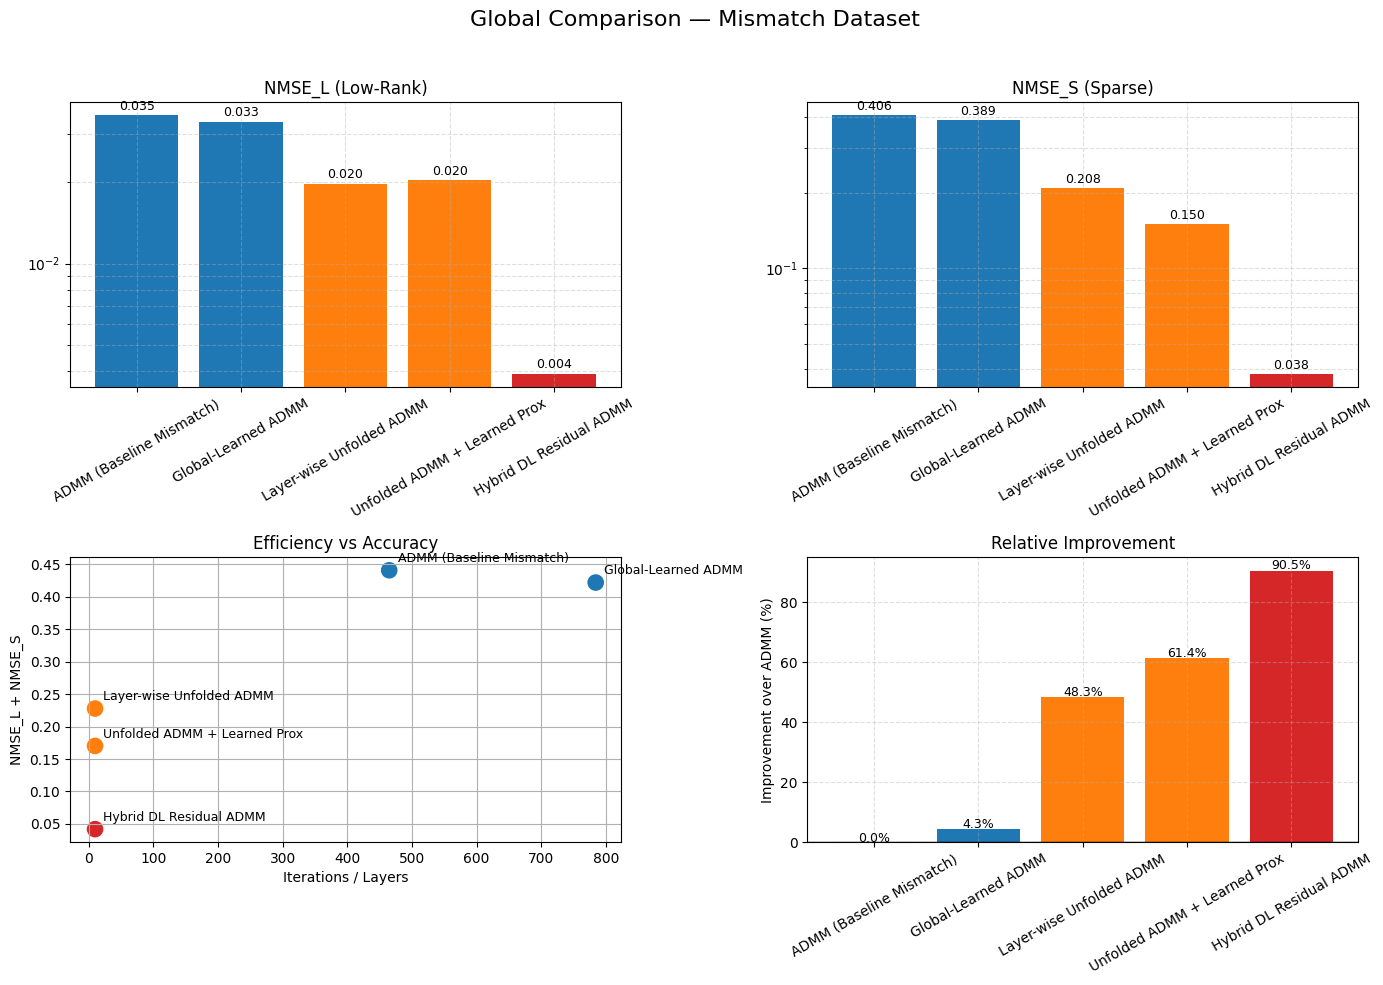


2x2 summary figure saved.


In [ ]:
# FINAL COMPARISON — Summary (Mismatch Dataset)

print("\n=== FINAL COMPARISON ===")

metrics_path = os.path.join(PROJECT_PATH, "results_metrics")
figures_path = os.path.join(PROJECT_PATH, "results_figures")

runs = [
    "RUN2_ADMM_BASELINE_MISMATCH",
    "RUN3_GLOBAL_LEARNED_ADMM",
    "RUN4_LAYERWISE_UNFOLDED_ADMM",
    "RUN5_UNFOLDED_ADMM_LEARNED_PROX",
    "RUN6_HYBRID_RESIDUAL_ADMM"
]

labels = [
    "ADMM (Baseline Mismatch)",
    "Global-Learned ADMM",
    "Layer-wise Unfolded ADMM",
    "Unfolded ADMM + Learned Prox",
    "Hybrid DL Residual ADMM"
]

nmse_L, nmse_S, complexity = [], [], []

for run in runs:
    data = np.load(os.path.join(metrics_path, f"{run}_metrics.npz"))
    nmse_L.append(data["NMSE_L_mean"])
    nmse_S.append(data["NMSE_S_mean"])
    complexity.append(data["Iterations_mean"])

nmse_L = np.array(nmse_L)
nmse_S = np.array(nmse_S)
complexity = np.array(complexity)

nmse_total = nmse_L + nmse_S

# Colors (model-based → hybrid progression)

colors = [
    "#1f77b4",  # ADMM
    "#1f77b4",  # Global learned
    "#ff7f0e",  # Unfolded
    "#ff7f0e",  # Unfolded + prox
    "#d62728"   # Hybrid
]

# Create 2x2 figure

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Global Comparison — Mismatch Dataset", fontsize=16)

x = np.arange(len(labels))

# 1) NMSE_L

ax = axes[0, 0]
ax.bar(x, nmse_L, color=colors)
ax.set_yscale("log")
ax.set_title("NMSE_L (Low-Rank)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30)
ax.grid(True, which="both", linestyle="--", alpha=0.4)

for i, v in enumerate(nmse_L):
    ax.text(i, v * 1.05, f"{v:.3f}", ha="center", fontsize=9)

# 2) NMSE_S

ax = axes[0, 1]
ax.bar(x, nmse_S, color=colors)
ax.set_yscale("log")
ax.set_title("NMSE_S (Sparse)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30)
ax.grid(True, which="both", linestyle="--", alpha=0.4)

for i, v in enumerate(nmse_S):
    ax.text(i, v * 1.05, f"{v:.3f}", ha="center", fontsize=9)

# 3) Efficiency vs Accuracy

ax = axes[1, 0]
ax.scatter(complexity, nmse_total, s=120, c=colors)

for i, txt in enumerate(labels):
    ax.annotate(
        txt,
        (complexity[i], nmse_total[i]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9
    )

ax.set_xlabel("Iterations / Layers")
ax.set_ylabel("NMSE_L + NMSE_S")
ax.set_title("Efficiency vs Accuracy")
ax.grid(True)

# 4) Relative improvement over baseline ADMM

baseline_total = nmse_total[0]
impr_total = (baseline_total - nmse_total) / baseline_total * 100

ax = axes[1, 1]
ax.bar(x, impr_total, color=colors)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30)
ax.set_ylabel("Improvement over ADMM (%)")
ax.set_title("Relative Improvement")
ax.grid(True, linestyle="--", alpha=0.4)

for i, v in enumerate(impr_total):
    ax.text(i, v + np.sign(v) * 0.5, f"{v:.1f}%", ha="center", fontsize=9)


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(figures_path, "FINAL_2x2_SUMMARY.png"), dpi=300)
plt.show()

print("\n2x2 summary figure saved.")
